<a href="https://colab.research.google.com/github/aaryachauhan123/AI-ML-Learning/blob/main/Copy_of_Image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Transfer learining using mobilenet

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.datasets import cifar10
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import matplotlib.pyplot as plt

In [ ]:
# 1 load cifar 10
(X_train,y_train),(X_test,y_test)=cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [ ]:
class_names = ['airplane','automobile','bird','animal','lion','fish','deer','dog','mountain','flower']

In [ ]:
# Normalize the dataset
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0


# Resize to 96x96 (MobileNetV2 needs larger input)
X_train = tf.image.resize(X_train, (96, 96))
X_test  = tf.image.resize(X_test, (96, 96))


# Make labels 1D (shape: (N,))
y_train = y_train.squeeze()
y_test  = y_test.squeeze()



In [ ]:
#2)load pretrained mobilenetV2(without top)
base_model = MobileNetV2(input_shape=(96,96,3),include_top=False,weights="imagenet")
base_model.trainable = False # option 1 : feture extractor

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
#3)Build model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation="relu"),
    layers.Dense(10,activation="softmax")
])

In [ ]:
#4)compile
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
from IPython.core import history
#5)Train
history = model.fit(
    X_train,y_train,
    epochs=2,
    batch_size=64,
    validation_data=(X_test,y_test)
)

Epoch 1/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 53ms/step - accuracy: 0.7559 - loss: 0.7050 - val_accuracy: 0.7915 - val_loss: 0.6094
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8080 - loss: 0.5447 - val_accuracy: 0.8047 - val_loss: 0.5643


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753,760 (10.50 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 330,518 (1.26 MB)

In [ ]:

#probability
probs = model.predict(X_test,batch_size=128)
y_preds = probs.argmax(axis=1)

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step


In [ ]:
#accuracy
ac = accuracy_score(y_test, preds)
print(ac)

0.8047


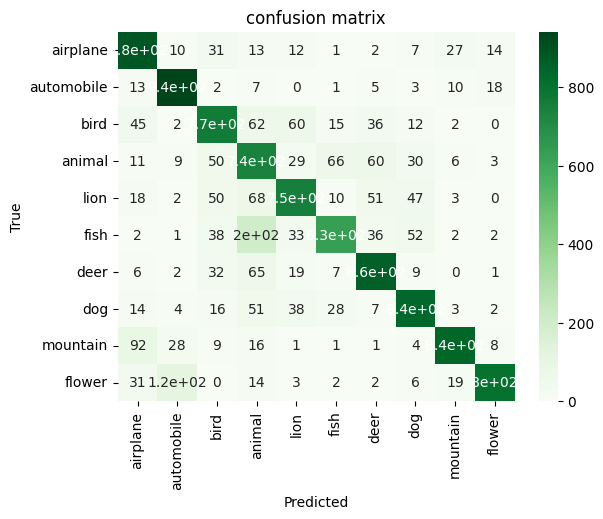

In [ ]:
#confusion matrix
import seaborn as sns
sns.heatmap(confusion_matrix(y_test,y_preds),annot=True,cmap='Greens',xticklabels=class_names,yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('confusion matrix')
plt.show()

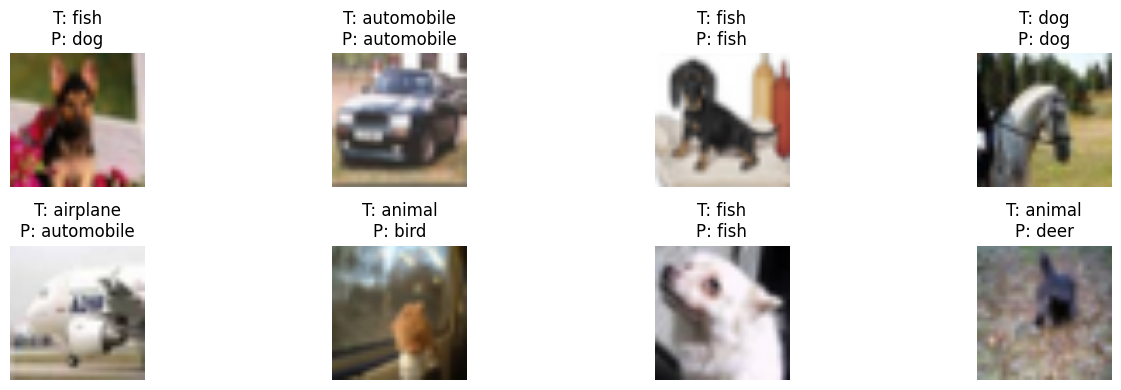

In [ ]:
#visualy dekhenge model ko

n = 8
idxs = np.random.choice(len(X_test), n, replace=False)


plt.figure(figsize=(14, 4))
for i, idx in enumerate(idxs):
    plt.subplot(2, 4, i+1)
    # x_test is a tensor; convert to numpy for plotting
    plt.imshow(X_test[idx].numpy())
    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_preds[idx]]
    plt.title(f"T: {true_label}\nP: {pred_label}")
    plt.axis("off")


plt.tight_layout()
plt.show()

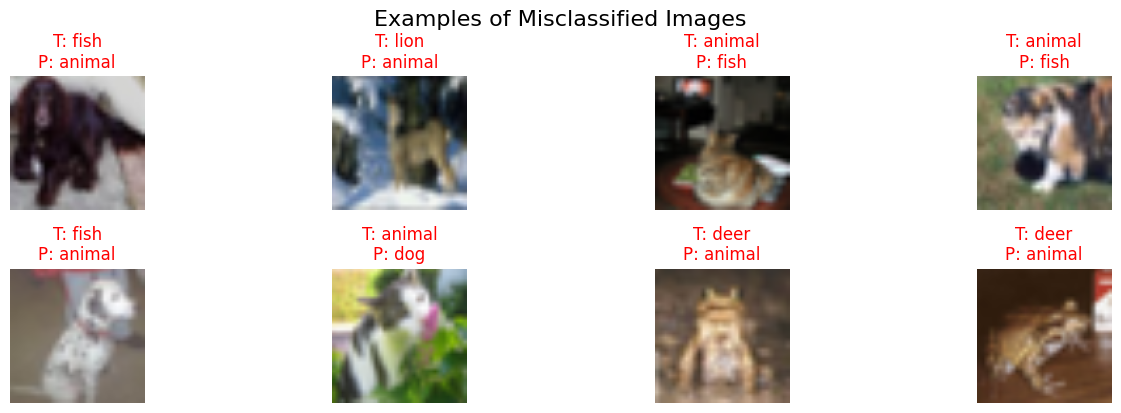

In [ ]:
#mera model kaha kaha wrong hai wo dekhne ke liye
misclassified_indices = np.where(y_test != y_preds)[0]

# Display up to 8 misclassified images
n_display = min(len(misclassified_indices), 8)
sample_misclassified_indices = np.random.choice(misclassified_indices, n_display, replace=False)

plt.figure(figsize=(14, 4))
for i, idx in enumerate(sample_misclassified_indices):
    plt.subplot(2, 4, i + 1)
    # Clip image values to [0, 1] to prevent matplotlib warnings
    plt.imshow(np.clip(X_test[idx].numpy(), 0, 1))
    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_preds[idx]]
    plt.title(f"T: {true_label}\nP: {pred_label}", color=('red' if true_label != pred_label else 'black'))
    plt.axis("off")

plt.tight_layout()
plt.suptitle("Examples of Misclassified Images", y=1.02, fontsize=16)
plt.show()